In [1]:
# os tools
import sys
import os
import os.path
import requests
import time
import urllib3
import shutil

# data tools
import numpy                 as np
import pandas                as pd
import xarray                as xr
from   datetime              import date, datetime, timedelta                 # for saving figures with today's date
import datetime
import scipy
from   scipy.stats           import kruskal              # for boxenplot stats
from   scipy.stats           import mannwhitneyu         # for split violin plot stats

# for all plots
import matplotlib
import matplotlib.pyplot     as plt                      # needed to make map setup
import matplotlib.colors     as colors
from   matplotlib.ticker     import EngFormatter         # for degree symbol in axis
from   cmocean               import cm as cmo
import seaborn               as     sns

# for map
import shapefile
import cartopy                                           # to make map
import matplotlib.path       as     mpath                # to draw circle for map
import cartopy.crs           as     ccrs                 # for map projection
import cartopy.feature       as     cfeature             # to add land features to map
# from   xhistogram.xarray     import histogram            # for map histogram
# from   mycolorpy             import colorlist as mcp     # to get n colors list
import pyproj  
import geopandas             as     gpd                  # for adding shapefiles of frontal zones 
from   osgeo                 import gdal
# import scikit_posthocs       as     sp                   # for stats


In [2]:
from importlib import reload
import mod_plotting as crplot

from mod_plotting import setup_SO_axes
plt.rcParams.update(crplot.my_params(size=12))

In [3]:
xr.set_options(display_expand_attrs = False)

In [4]:
import shapefile
so_fronts = shapefile.Reader('./shapefiles/fronts/so_fronts.shp') 
stf_mod   = shapefile.Reader('./shapefiles/fronts/stf_mod/stf_mod.shp')

stf  = stf_mod.shape(0).points
saf  = so_fronts.shape(1).points
pf   = so_fronts.shape(2).points
sacc = so_fronts.shape(3).points
sie  = so_fronts.shape(4).points

In [5]:
max_latitude:          float = -30
add_gridlines:         bool  = True
color_land:            bool  = False
land_edgecolor:        str   = 'grey'
land_facecolor:        str   = 'grey'
fontsize:              float = 10
map_facecolor:         str   = 'white'
coast_linewidth:       float = 0.3
gridlines_linewidth:   float = 0.5
girdlines_color:       str   = 'grey'
gridlines_alpha:       float = 0.5
longitude_label_color: str   = 'grey'
latitude_label_color:  str   = 'grey'

# Import .nc files from 0.2_DataProcessing_Argopy

In [6]:
# Downloaded using research mode, so all have been QC'ed
core_profiles = xr.open_dataset('../data/argopy_jan2014_core_profiles_2025Jan23.nc')
core_index = pd.read_csv('../data/argopy_jan2014_core_index_2025Jan23.csv', index_col=0)

In [7]:
# BGC downloads are expert mode only, so need to QC manually
bgc_profiles = xr.open_dataset('../data/argopy_jan2014_bgc_profiles_2025Jan23.nc')
bgc_index = pd.read_csv('../data/argopy_jan2014_bgc_index_2025Jan23.csv', index_col=0)

In [531]:
# Example float with longer trajectory
example_profiles = xr.open_dataset('../data/argopy_example_1900857.nc')

In [544]:
# Example BGC float with pH data
example_bgc = xr.open_dataset('../data/argopy_5906030_bgc_profiles_2025Jan29.nc')

In [8]:
core_index

,date,latitude,longitude,wmo,cyc
0,2014-01-02 02:34:12,-40.358,95.357,1900410,260
1,2014-01-12 06:35:16,-40.109,96.083,1900410,261
2,2014-01-22 10:36:20,-40.247,96.676,1900410,262
3,2014-01-03 15:42:43,-53.679,-132.262,1900724,225
4,2014-01-13 19:45:50,-54.242,-129.889,1900724,226
...,...,...,...,...,...
2287,2014-01-14 16:00:54,-41.760,-40.475,7900419,8
2288,2014-01-24 16:09:04,-40.947,-38.533,7900419,9
2289,2014-01-05 21:32:31,-47.482,-44.977,7900420,7
2290,2014-01-16 00:45:21,-47.540,-44.008,7900420,8


In [7]:
core_profiles

<xarray.Dataset>
Dimensions:          (N_PROF: 2292, N_LEVELS: 1009)
Coordinates:
  * N_PROF           (N_PROF) int64 259 1332 1521 1677 ... 1535 1111 1775 1581
  * N_LEVELS         (N_LEVELS) int64 0 1 2 3 4 5 ... 1004 1005 1006 1007 1008
    LATITUDE         (N_PROF) float64 ...
    LONGITUDE        (N_PROF) float64 ...
    TIME             (N_PROF) datetime64[ns] ...
Data variables:
    CYCLE_NUMBER     (N_PROF) int64 ...
    DIRECTION        (N_PROF) object ...
    PLATFORM_NUMBER  (N_PROF) int64 ...
    PRES             (N_PROF, N_LEVELS) float32 ...
    PRES_ERROR       (N_PROF, N_LEVELS) float32 ...
    PSAL             (N_PROF, N_LEVELS) float32 ...
    PSAL_ERROR       (N_PROF, N_LEVELS) float32 ...
    TEMP             (N_PROF, N_LEVELS) float32 ...
    TEMP_ERROR       (N_PROF, N_LEVELS) float32 ...
Attributes:
    DATA_ID:              ARGO
    DOI:                  http://doi.org/10.17882/42182
    Fetched_from:         https://erddap.ifremer.fr/erddap
    Fetched_by:           sangminsong
    Fetched_date:         2025/01/23
    Fetched_constraints:  [x=-180.00/-160.00; y=-90.00/-71.67; z=0.0/500.0; t...
    Fetched_uri:          ['https://erddap.ifremer.fr/erddap/tabledap/ArgoFlo...
    history:              Variables filtered according to DATA_MODE; Variable...

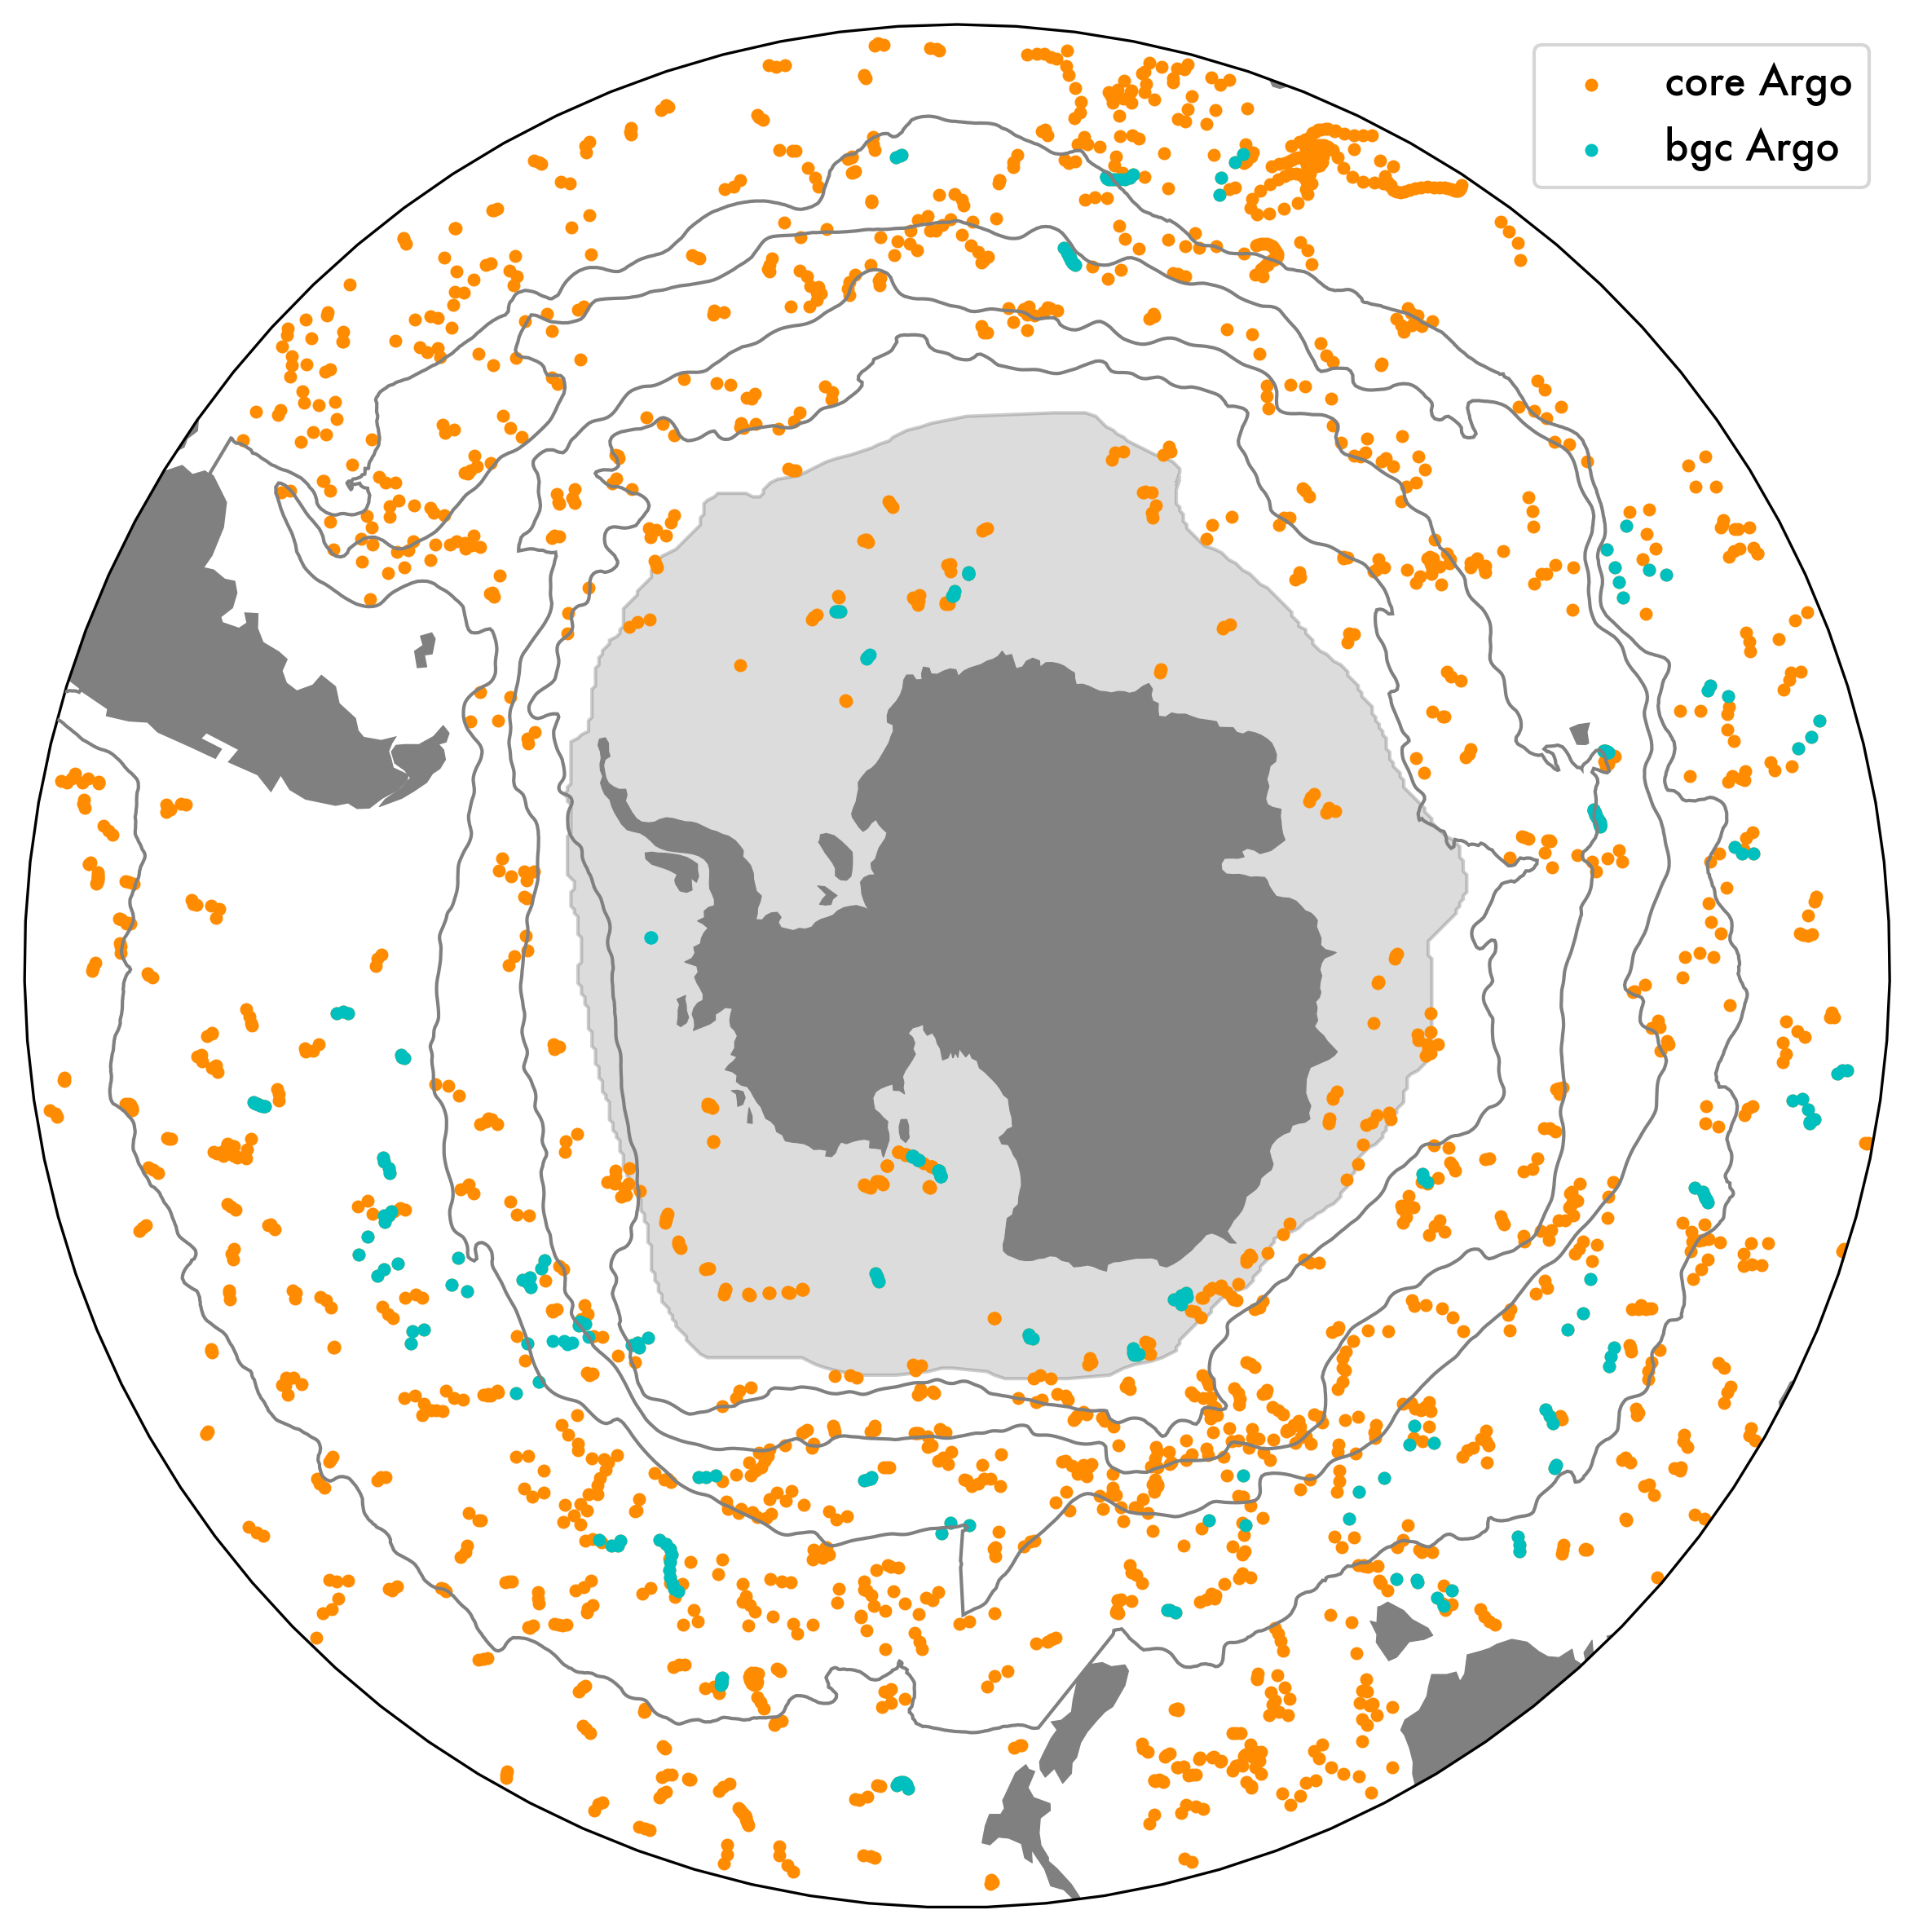

In [8]:
# Map projection of core profile locations

data = core_index

# Choose projection
map_proj = ccrs.SouthPolarStereo()
# map_proj = ccrs.PlateCarree()

fig  = plt.figure(figsize=[10, 10], dpi=300) # inches
ax1  = plt.subplot(projection = map_proj)

# Set up plot axes
crplot.setup_SO_axes(ax1, fig , 
                              add_gridlines         = False, 
                              color_land            = True,
                              land_facecolor        = land_facecolor,
                              land_edgecolor        = land_edgecolor,
                              fontsize              = 14,
                              max_latitude         = -35,
                              map_facecolor         = 'white',
                              coast_linewidth       = coast_linewidth)

# data = expo_dict[expocode]
# ax1.scatter(data.longitude, data.latitude, c='k', alpha=0.2, s=2, transform=ccrs.PlateCarree(), label='')
ax1.scatter(core_index.longitude, core_index.latitude, c='darkorange', s=8, transform=ccrs.PlateCarree(), label='core Argo')
ax1.scatter(bgc_index.longitude, bgc_index.latitude, c='c', s=8, transform=ccrs.PlateCarree(), label='bgc Argo')
ax1.legend()


### Add front and sea ice edge
stf_patch  = plt.Polygon(stf,  fill=False, edgecolor='grey',   zorder=15)
saf_patch  = plt.Polygon(saf,  fill=False, edgecolor='grey',   zorder=14)
pf_patch   = plt.Polygon(pf,   fill=False, edgecolor='grey',    zorder=13)
sacc_patch = plt.Polygon(sacc, fill=False, edgecolor='grey',  zorder=12)
sie_patch  = plt.Polygon(sie,  fill=True,  edgecolor='grey',   zorder=0,  facecolor='darkgrey', alpha=0.4)

ax1.add_patch(stf_patch)
ax1.add_patch(saf_patch)
ax1.add_patch(pf_patch)
ax1.add_patch(sacc_patch)
ax1.add_patch(sie_patch)

In [10]:
core_profiles

<xarray.Dataset>
Dimensions:          (N_PROF: 2292, N_LEVELS: 1009)
Coordinates:
  * N_PROF           (N_PROF) int64 259 1332 1521 1677 ... 1535 1111 1775 1581
  * N_LEVELS         (N_LEVELS) int64 0 1 2 3 4 5 ... 1004 1005 1006 1007 1008
    LATITUDE         (N_PROF) float64 ...
    LONGITUDE        (N_PROF) float64 ...
    TIME             (N_PROF) datetime64[ns] ...
Data variables:
    CYCLE_NUMBER     (N_PROF) int64 ...
    DIRECTION        (N_PROF) object ...
    PLATFORM_NUMBER  (N_PROF) int64 ...
    PRES             (N_PROF, N_LEVELS) float32 ...
    PRES_ERROR       (N_PROF, N_LEVELS) float32 ...
    PSAL             (N_PROF, N_LEVELS) float32 ...
    PSAL_ERROR       (N_PROF, N_LEVELS) float32 ...
    TEMP             (N_PROF, N_LEVELS) float32 ...
    TEMP_ERROR       (N_PROF, N_LEVELS) float32 ...
Attributes: (8)

# Process core Argo data

## Dataframe setup

In [41]:
import gsw
import mod_cremas as crx 
from mod_cremas import ytd2datetime, datetime2ytd

# Custom module
import mod_argo 
reload(mod_argo)


In [ ]:
# Make dataframes using the custom Argo module
reload(mod_argo)
temp = core_profiles.to_dataframe()
core_dict = {key:mod_argo.process_core_float(group, var_list = 'default', 
                                    ref_time= '2014-01-01') for key,group in temp.groupby('PLATFORM_NUMBER')}

# coreDF = pd.concat(core_dict.values(), ignore_index=True).set_index(['profid', 'pressure'])
# wmoids = coreDF.wmoid.unique()
# random_float = core_dict[np.random.choice(wmoids)]

In [522]:
coreDF = pd.concat(core_dict.values(), ignore_index=True).set_index(['profid', 'pressure'])
coreDF

wmoid  latitude  longitude            datetime  \
profid        pressure                                                        
1900410_id260 6.400000     1900410   -40.358     95.357 2014-01-02 02:34:12   
              10.200000    1900410   -40.358     95.357 2014-01-02 02:34:12   
              19.299999    1900410   -40.358     95.357 2014-01-02 02:34:12   
              30.500000    1900410   -40.358     95.357 2014-01-02 02:34:12   
              40.000000    1900410   -40.358     95.357 2014-01-02 02:34:12   
...                            ...       ...        ...                 ...   
7900420_id009 NaN          7900420   -47.028    -43.566 2014-01-26 00:51:20   
              NaN          7900420   -47.028    -43.566 2014-01-26 00:51:20   
              NaN          7900420   -47.028    -43.566 2014-01-26 00:51:20   
              NaN          7900420   -47.028    -43.566 2014-01-26 00:51:20   
              NaN          7900420   -47.028    -43.566 2014-01-26 00:51:20   

                             yearday         CT         SA     sigma0  \
profid        pressure                                                  
1900410_id260 6.400000      1.107083  12.707135  35.034611  26.352269   
              10.200000     1.107083  12.700624  35.034618  26.353562   
              19.299999     1.107083  12.699379  35.035599  26.354560   
              30.500000     1.107083  12.691850  35.036612  26.356826   
              40.000000     1.107083  12.694570  35.036612  26.356288   
...                              ...        ...        ...        ...   
7900420_id009 NaN          25.035648        NaN        NaN        NaN   
              NaN          25.035648        NaN        NaN        NaN   
              NaN          25.035648        NaN        NaN        NaN   
              NaN          25.035648        NaN        NaN        NaN   
              NaN          25.035648        NaN        NaN        NaN   

                              spice  temperature   salinity  temp_error  \
profid        pressure                                                    
1900410_id260 6.400000     1.689550       12.716  34.869999       0.002   
              10.200000    1.688213       12.710  34.869999       0.002   
              19.299999    1.688675       12.710  34.870998       0.002   
              30.500000    1.687866       12.704  34.872002       0.002   
              40.000000    1.688427       12.708  34.872002       0.002   
...                             ...          ...        ...         ...   
7900420_id009 NaN               NaN          NaN        NaN         NaN   
              NaN               NaN          NaN        NaN         NaN   
              NaN               NaN          NaN        NaN         NaN   
              NaN               NaN          NaN        NaN         NaN   
              NaN               NaN          NaN        NaN         NaN   

                           psal_error  pres_error  cycle_number  
profid        pressure                                           
1900410_id260 6.400000           0.01         2.4           260  
              10.200000          0.01         2.4           260  
              19.299999          0.01         2.4           260  
              30.500000          0.01         2.4           260  
              40.000000          0.01         2.4           260  
...                               ...         ...           ...  
7900420_id009 NaN                 NaN         NaN             9  
              NaN                 NaN         NaN             9  
              NaN                 NaN         NaN             9  
              NaN                 NaN         NaN             9  
              NaN                 NaN         NaN             9  

[2312628 rows x 15 columns]

### Diagnosing pressure duplication issue 

- Noticed errors when doing pchip interpolation (x must be monotonically increasing) 
- Repeated pressure levels for certain floats, simply remove one row

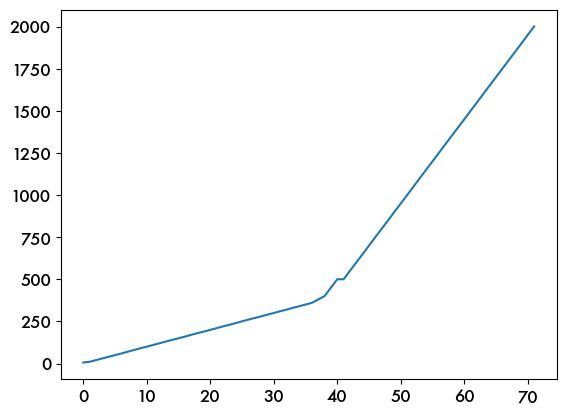

In [302]:
temp = core_dict[np.random.choice(wmoids)].reset_index()
# temp = argodat[argodat.cycle_number == 68]
# temp = temp.drop_duplicates(subset='pressure', keep="last")

# plt.scatter(temp.pressure, temp.CT)
plt.plot(temp.index, temp.pressure)


In [309]:
temp.iloc[40:43]

,index,wmoid,profid,latitude,longitude,datetime,yearday,pressure,CT,SA,sigma0,spice,temperature,psal,temp_error,psal_error,pres_error,cycle_number
40,40,6901976,6901976.001,-52.768,-49.659,2014-01-23 17:02:56,22.71037,500.600006,2.250414,34.345395,27.299002,-0.400840,2.276,34.180740,0.002,0.01,2.4,1
41,41,6901976,6901976.001,-52.768,-49.659,2014-01-23 17:02:56,22.71037,500.600006,2.250414,34.345395,27.299002,-0.400840,2.276,34.180740,0.002,0.01,2.4,1
42,42,6901976,6901976.001,-52.768,-49.659,2014-01-23 17:02:56,22.71037,551.200012,2.811438,34.477223,27.356154,-0.254992,2.844,34.311722,0.002,0.01,2.4,1


In [ ]:
reload(mod_argo)
temp = bgc_profiles.to_dataframe()

In [ ]:
# Example from SOGOS. For BGC
#  def make_float_df(wmo, floatDSdict):
#         """
#         Return dataframe from a single float dataset
#         @param:
#                 wmo (int)
#                 floatDSdict (dict): dictionary of float datasets
#         """
#         temp = floatDSdict[str(wmo)]
#         float_df = temp[['JULD','LATITUDE', 'LONGITUDE','PRES_ADJUSTED','TEMP_ADJUSTED','PSAL_ADJUSTED',
#                          'DOXY_ADJUSTED','NITRATE_ADJUSTED', # , 'PH_IN_SITU_TOTAL_ADJUSTED','BBP700_ADJUSTED', 
#                         'JULD_QC', 'POSITION_QC', 'PRES_ADJUSTED_QC', 'TEMP_ADJUSTED_QC','PSAL_ADJUSTED_QC', 
#                         'DOXY_ADJUSTED_QC', 'NITRATE_ADJUSTED_QC']].to_dataframe() #'BBP700_ADJUSTED_QC' #, 'PH_IN_SITU_TOTAL_ADJUSTED_QC',
#         dtimes = pd.to_datetime(float_df.JULD.values, unit='D', origin=pd.Timestamp('1950-01-01'))
#         float_df['yearday'] = sg.datetime2ytd(dtimes)
#         float_df['wmoid'] = np.repeat(wmo, len(float_df))


#         # need to get the profile number from the index
#         # create a 10-digit unique id so easy to sort later
#         prof = float_df.index.get_level_values(0)
#         prof = prof.astype(str); prof = [tag.zfill(3) for tag in prof]
#         float_df['profid'] = [str(wmo)+tag for tag in prof]


#         qc_keys = ['JULD_QC', 'POSITION_QC', 'PRES_ADJUSTED_QC', 'TEMP_ADJUSTED_QC', 'PSAL_ADJUSTED_QC',
#             'DOXY_ADJUSTED_QC', 'NITRATE_ADJUSTED_QC'] #, 'PH_IN_SITU_TOTAL_ADJUSTED_QC', 'BBP700_ADJUSTED_QC']
#         for key in qc_keys:  #qc flags are not stored as ints so we can convert
#                 newlist = []
#                 for qc in float_df[key]:
#                         if str(qc)[2] == 'n': newlist.append('NaN')
#                         else: newlist.append(str(qc)[2])
#                 float_df[key] = newlist
        
#         float_df.rename(columns={'LATITUDE':'lat','LONGITUDE':'lon',
#                         'PRES_ADJUSTED': 'pressure', 'TEMP_ADJUSTED': 'temperature', 'PSAL_ADJUSTED': 'salinity',
#                         'DOXY_ADJUSTED': 'oxygen', 'NITRATE_ADJUSTED':'nitrate'}, inplace=True)
#                         # 'PH_IN_SITU_TOTAL_ADJUSTED': 'pH', 'BBP700_ADJUSTED': 'bbp700'
#         float_df.rename(columns={'JULD_QC': 'juld_qc', 'POSITION_QC': 'position_qc', 
#                         'PRES_ADJUSTED_QC': 'pressure_qc', 'TEMP_ADJUSTED_QC': 'temperature_qc','PSAL_ADJUSTED_QC': 'salinity_qc',
#                         'DOXY_ADJUSTED_QC': 'oxygen_qc', 'NITRATE_ADJUSTED_QC': 'nitrate_qc'}, inplace=True) 
#                         # 'PH_IN_SITU_TOTAL_ADJUSTED_QC': 'pH_qc','BBP700_ADJUSTED_QC': 'bbp700_qc'

        
#         float_df['SA']= gsw.SA_from_SP(float_df['salinity'],float_df['pressure'],float_df['lon'],float_df['lat'])
#         float_df['CT'] = gsw.CT_from_t(float_df['SA'], float_df['temperature'], float_df['pressure']) # change Sp to SA, jun24

#         # # Add training variables Sigma0 and Spice as desired
#         float_df['sigma0'] = gsw.sigma0(float_df.SA.values, float_df.CT.values)
#         float_df['spice'] = gsw.spiciness0(float_df["SA"].values, float_df["CT"].values)

#         # Add oxygen saturation and drho/dz
#         float_df = float_df[dvars + qcvars]

#         return float_df


### To-do here for Jan 28

Stuff looks good for core Argo, committed to git. 
Now need to repeat for bgc argo. 


In [ ]:
# Modify to work for bgc-floats, jan 24
# this is a modified version of mod_argo process_core_float

def process_argo_float(float_df, var_list = 'bgc', ref_time = '2014-01-01'):
    """
    Return dataframe from a single float dataset accessed with Argopy. 
    Assumed to be used in 'research' mode, i.e. already quality-controlled for core Argo. 
    Can only be in 'expert' mode for BGC floats, need to add QC variables manually.

    @param:
            float_df (dict):  single float Dataframe, accessed in 'research' mode for core
                                only 'expert' mode available for BGC floats 
            var_list : list of variables to include in the final dataframe, or 'phys'
            ref_time : reference time for yearday calculation
    @return:
            float_df (pd.DataFrame): 
    """
    float_df = float_df.reset_index()

    # if var_list == 'phys': # research mode
    #     new_columns = {'LATITUDE':'latitude','LONGITUDE':'longitude', 'TIME':'datetime', 'CYCLE_NUMBER':'cycle_number',
    #                             'PLATFORM_NUMBER':'wmoid', 'PRES':'pressure', 'TEMP':'temperature', 'PSAL':'salinity',
    #                             'PRES_ERROR': 'pres_error', 'PSAL_ERROR': 'psal_error', 'TEMP_ERROR': 'temp_error'}
    if var_list == 'bgc': # expert mode
        new_columns = {'LATITUDE':'latitude','LONGITUDE':'longitude', 'TIME':'datetime', 'CYCLE_NUMBER':'cycle_number',
                                'PLATFORM_NUMBER':'wmoid', 'PRES':'pressure', 'TEMP':'temperature', 'PSAL':'salinity',
                                'PRES_ERROR': 'pres_error', 'PSAL_ERROR': 'psal_error', 'TEMP_ERROR': 'temp_error',
                                'PH_'}


    float_df.rename(columns=new_columns, inplace=True)
    float_df['yearday'] = myocn.datetime2ytd(float_df['datetime'], ref_time = ref_time)

    # Create a 10-digit unique id so easy to sort later
    # Make sure strings are filled so 1st and 10th profile are different
    prof = [tag.zfill(3) for tag in float_df['cycle_number'].astype(str)]
    float_df['profid'] = [str(float_df.wmoid[0]) + '_id' + tag for tag in prof]

    # Add calculated variables using gsw
    float_df['SA']= gsw.SA_from_SP(float_df['salinity'],float_df['pressure'],float_df['longitude'],float_df['latitude'])
    float_df['CT'] = gsw.CT_from_t(float_df['SA'], float_df['temperature'], float_df['pressure']) 
    float_df['sigma0'] = gsw.sigma0(float_df.SA.values, float_df.CT.values)
    float_df['spice'] = gsw.spiciness0(float_df["SA"].values, float_df["CT"].values)

    if var_list == 'phys':
        var_list = ['wmoid', 'profid', 'latitude', 'longitude', 'datetime', 'yearday',
            'pressure', 'CT', 'SA', 'sigma0', 'spice',
            'temperature', 'salinity',
            'temp_error', 'psal_error', 'pres_error', 'cycle_number']
    elif var_list == 'bgc':
        var_list = []

    float_df = float_df[var_list]

    return float_df




In [542]:
bgc_profiles

<xarray.Dataset>
Dimensions:                            (N_PROF: 281, N_LEVELS: 1406)
Coordinates:
  * N_PROF                             (N_PROF) int64 164 110 181 ... 38 253 202
  * N_LEVELS                           (N_LEVELS) int64 0 1 2 ... 1403 1404 1405
    LATITUDE                           (N_PROF) float64 ...
    LONGITUDE                          (N_PROF) float64 ...
    TIME                               (N_PROF) datetime64[ns] ...
Data variables: (12/78)
    BBP700                             (N_PROF, N_LEVELS) float32 ...
    BBP700_ADJUSTED                    (N_PROF, N_LEVELS) float32 ...
    BBP700_ADJUSTED_ERROR              (N_PROF, N_LEVELS) float32 ...
    BBP700_ADJUSTED_QC                 (N_PROF, N_LEVELS) int64 ...
    BBP700_DATA_MODE                   (N_PROF, N_LEVELS) object ...
    BBP700_QC                          (N_PROF, N_LEVELS) int64 ...
    ...                                 ...
    TEMP_ADJUSTED                      (N_PROF, N_LEVELS) float32 ...
    TEMP_ADJUSTED_ERROR                (N_PROF, N_LEVELS) float32 ...
    TEMP_ADJUSTED_QC                   (N_PROF, N_LEVELS) int64 ...
    TEMP_DATA_MODE                     (N_PROF, N_LEVELS) object ...
    TEMP_QC                            (N_PROF, N_LEVELS) int64 ...
    TIME_QC                            (N_PROF) int64 ...
Attributes: (8)

## Interpolation


At this point,

* core_dict:        dictionary of core Argo Dataframes, without interpolation (keys: wmo)
* core_argo_DF:     Dataframe with all core_argo floats

Now interpolate onto chosen regular pressure levels. 

In [ ]:
# Interpolate the data to a regular pressure grid 
# Uses pchip interpolation (see mod_argo) without extrapolation
pres_regular = np.arange(0,1002,2)

# reload(mod_argo)
coreDF_regular = mod_argo.interpolate_float_pressure(coreDF, pres_regular, var_list = 'phys', ref_time = '2014-01-01')
coreDF_regular

CT         SA     sigma0     spice  \
profid        pressure                                              
1900410_id260 8         12.703588  35.034612  26.352913  1.688786   
              10        12.700706  35.034618  26.353524  1.688219   
              12        12.700228  35.034694  26.353830  1.688260   
              14        12.699990  35.034902  26.354039  1.688387   
              16        12.699831  35.035176  26.354209  1.688537   
...                           ...        ...        ...       ...   
7900420_id009 992        2.914044  34.529310  27.388254 -0.207944   
              994        2.912724  34.530503  27.389333 -0.207257   
              996        2.911343  34.531672  27.390402 -0.206600   
              998        2.909896  34.532814  27.391461 -0.205977   
              1000       2.908376  34.533928  27.392508 -0.205388   

                        temperature   salinity    yearday  latitude  \
profid        pressure                                                
1900410_id260 8           12.712608  34.869999   1.107083   -40.358   
              10          12.710028  34.869999   1.107083   -40.358   
              12          12.710000  34.870072   1.107083   -40.358   
              14          12.710000  34.870285   1.107083   -40.358   
              16          12.710000  34.870567   1.107083   -40.358   
...                             ...        ...        ...       ...   
7900420_id009 992          2.979395  34.363052  25.035648   -47.028   
              994          2.978236  34.364231  25.035648   -47.028   
              996          2.977019  34.365385  25.035648   -47.028   
              998          2.975737  34.366512  25.035648   -47.028   
              1000         2.974385  34.367611  25.035648   -47.028   

                        longitude    wmoid            datetime  
profid        pressure                                          
1900410_id260 8            95.357  1900410 2014-01-02 02:34:12  
              10           95.357  1900410 2014-01-02 02:34:12  
              12           95.357  1900410 2014-01-02 02:34:12  
              14           95.357  1900410 2014-01-02 02:34:12  
              16           95.357  1900410 2014-01-02 02:34:12  
...                           ...      ...                 ...  
7900420_id009 992         -43.566  7900420 2014-01-26 00:51:20  
              994         -43.566  7900420 2014-01-26 00:51:20  
              996         -43.566  7900420 2014-01-26 00:51:20  
              998         -43.566  7900420 2014-01-26 00:51:20  
              1000        -43.566  7900420 2014-01-26 00:51:20  

[1005909 rows x 11 columns]

In [534]:
# Non-interpolated example float
# reload(mod_argo)
example_df = mod_argo.process_core_float(example_profiles.to_dataframe(), var_list = 'default', 
                                    ref_time= '2014-01-01').set_index(['profid', 'pressure'])

# Interpolated example float
pres_regular = np.arange(0,1002,2)
example_df_regular = mod_argo.interpolate_float_pressure(example_df, pres_regular, var_list = 'phys', ref_time = '2014-01-01')

In [509]:
dot_small = 2
dot_large = 18

['1900857_id185' '1900857_id125' '1900857_id072' '1900857_id168'
 '1900857_id062' '1900857_id026' '1900857_id158' '1900857_id016'
 '1900857_id190' '1900857_id130']


Text(0.5, 1.0, 'interpolated to dbars [0,1002,2]')

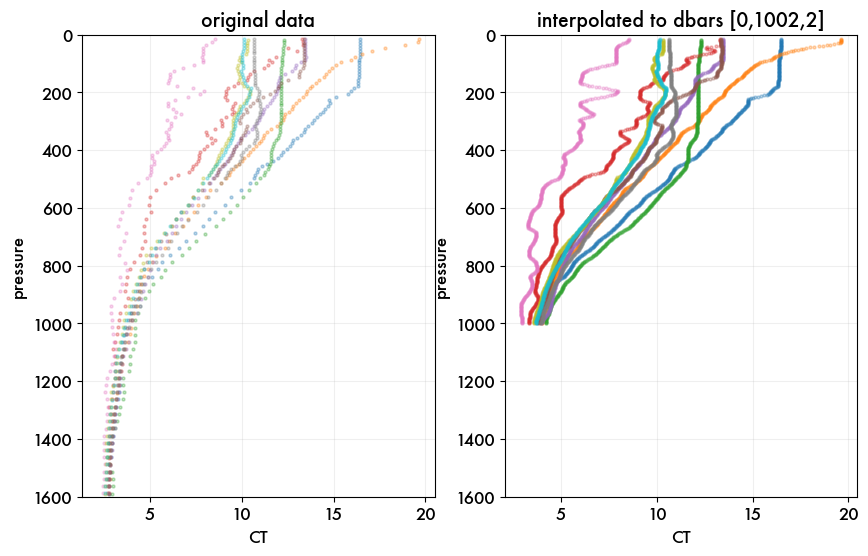

In [547]:
# Diagnostic plot for interpolation function from mod_argo
reload(mod_argo)

# # List of profile ids to plot
# wmokey = 1900857  # wmo, example initialized earlier
# ixlist = [12, 16, 20, 24] # specific cycle numbers to plot
# list_profids = [str(wmokey) + '_id' + str(x).zfill(3) for x in ixlist] #['1900857_id001', '1900857_id002']
list_profids = np.random.choice(example_df.index.get_level_values('profid').unique(), 10)
original_data = example_df.loc[list_profids]
interp_data = example_df_regular.loc[list_profids]

# # Plot random profiles from coreDF
# profids = coreDF.reset_index().profid.unique()
# list_profids = np.random.choice(profids, 10)
# original_data = coreDF.loc[list_profids]
# interp_data = coreDF_regular.loc[list_profids]

# =====
print(list_profids) 

fig = plt.figure(figsize=(10,6))
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)
mod_argo.plot_profiles_from_WMO(original_data, var='CT', ax=ax1, dotsize=dot_large)
mod_argo.plot_profiles_from_WMO(interp_data, var='CT', ax=ax2, dotsize=dot_large)

ax1.set_title('original data');
ax2.set_title('interpolated to dbars [0,1002,2]')

## Convert to xarray Dataset

In [ ]:
# Convert to xarray Dataset
title = 'Jan 2014 Core floats, interpolated to regular pressure grid [0,1000,2]'
source = 'Argopy, research mode'
reload(mod_argo)

# Make main dataset
coreDS = mod_argo.to_xr_dataset(coreDF_regular, title, source)
# Get averaged by profile (e.g. for profile location plotting)
coreDS_byProfile = coreDS.mean(dim='profid')

coreDS

/Users/sangminsong/Library/CloudStorage/OneDrive-UW/Code/CREMAS/src/mod_argo.py:134: UserWarning: Converting non-nanosecond precision datetime values to nanosecond precision. This behavior can eventually be relaxed in xarray, as it is an artifact from pandas which is now beginning to support non-nanosecond precision values. This warning is caused by passing non-nanosecond np.datetime64 or np.timedelta64 values to the DataArray or Variable constructor; it can be silenced by converting the values to nanosecond precision ahead of time.
/Users/sangminsong/Library/CloudStorage/OneDrive-UW/Code/CREMAS/src/mod_argo.py:134: UserWarning: Converting non-nanosecond precision datetime values to nanosecond precision. This behavior can eventually be relaxed in xarray, as it is an artifact from pandas which is now beginning to support non-nanosecond precision values. This warning is caused by passing non-nanosecond np.datetime64 or np.timedelta64 values to the DataArray or Variable constructor; it ca

<xarray.Dataset>
Dimensions:      (profid: 2292, pressure: 500)
Coordinates:
  * profid       (profid) object '1900410_id260' ... '7900420_id009'
  * pressure     (pressure) int64 2 4 6 8 10 12 14 ... 990 992 994 996 998 1000
    yearday      (profid, pressure) float64 nan nan nan ... 25.04 25.04 25.04
    latitude     (profid, pressure) float64 nan nan nan ... -47.03 -47.03 -47.03
    longitude    (profid, pressure) float64 nan nan nan ... -43.57 -43.57 -43.57
    wmoid        (profid, pressure) float64 nan nan nan ... 7.9e+06 7.9e+06
    datetime     (profid, pressure) datetime64[ns] NaT ... 2014-01-26T00:51:20
Data variables:
    CT           (profid, pressure) float64 nan nan nan ... 2.911 2.91 2.908
    SA           (profid, pressure) float64 nan nan nan ... 34.53 34.53 34.53
    sigma0       (profid, pressure) float64 nan nan nan ... 27.39 27.39 27.39
    spice        (profid, pressure) float64 nan nan nan ... -0.206 -0.2054
    temperature  (profid, pressure) float64 nan nan nan ... 2.977 2.976 2.974
    salinity     (profid, pressure) float64 nan nan nan ... 34.37 34.37 34.37
Attributes: (3)

# Single float diagnostics

In [414]:
# Prepare for plotting histogram of profile locations
# Longitude and latitude range
lon_min = -180
lon_max =  180
lat_min = -85
lat_max = -30

# depth range
zmin = 20.0
zmax = 1000.0

# ranges
lon_range   = (lon_min, lon_max)
lat_range   = (lat_min, lat_max)
depth_range = (zmin, zmax)

# temperature and salinity ranges for plotting
Trange    = (-2.2, 6.0)
Srange    = (33.5, 35.0)
sig0range = (26.6, 28.0)

import file_io as io
bds = io.load_bathymetry('bathy.nc')
bathy_lon = bds['lon'][:]
bathy_lat = bds['lat'][:]
bathy = bds['bathy'][:]

file_io.load_bathymetry


In [538]:
reload(crx)
anyfloat, anywmo = crx.get_random_wmo(coreDS)
anyfloat

<xarray.Dataset>
Dimensions:      (profid: 3, pressure: 500)
Coordinates:
  * profid       (profid) object '7900401_id040' '7900401_id041' '7900401_id042'
  * pressure     (pressure) int64 2 4 6 8 10 12 14 ... 990 992 994 996 998 1000
    yearday      (profid, pressure) float64 7.852 7.852 7.852 ... 27.85 27.85
    latitude     (profid, pressure) float64 -60.93 -60.93 ... -60.42 -60.42
    longitude    (profid, pressure) float64 -41.83 -41.83 ... -44.25 -44.25
    wmoid        (profid, pressure) float64 7.9e+06 7.9e+06 ... 7.9e+06 7.9e+06
    datetime     (profid, pressure) datetime64[ns] 2014-01-08T20:27:34 ... 20...
Data variables:
    CT           (profid, pressure) float64 -1.425 -1.429 ... 0.3524 0.3518
    SA           (profid, pressure) float64 33.49 33.49 33.5 ... 34.85 34.85
    sigma0       (profid, pressure) float64 26.82 26.82 26.82 ... 27.84 27.84
    spice        (profid, pressure) float64 -1.229 -1.229 ... -0.1961 -0.1962
    temperature  (profid, pressure) float64 -1.43 -1.434 ... 0.3984 0.3979
    salinity     (profid, pressure) float64 33.33 33.33 33.34 ... 34.68 34.68
Attributes: (3)

Dates: 		2014-01-04 06:54:05 to 2014-01-24 04:39:55
Latitude:	-38.38544 to -35.62227
Longitude:	-49.3166 to -47.56482


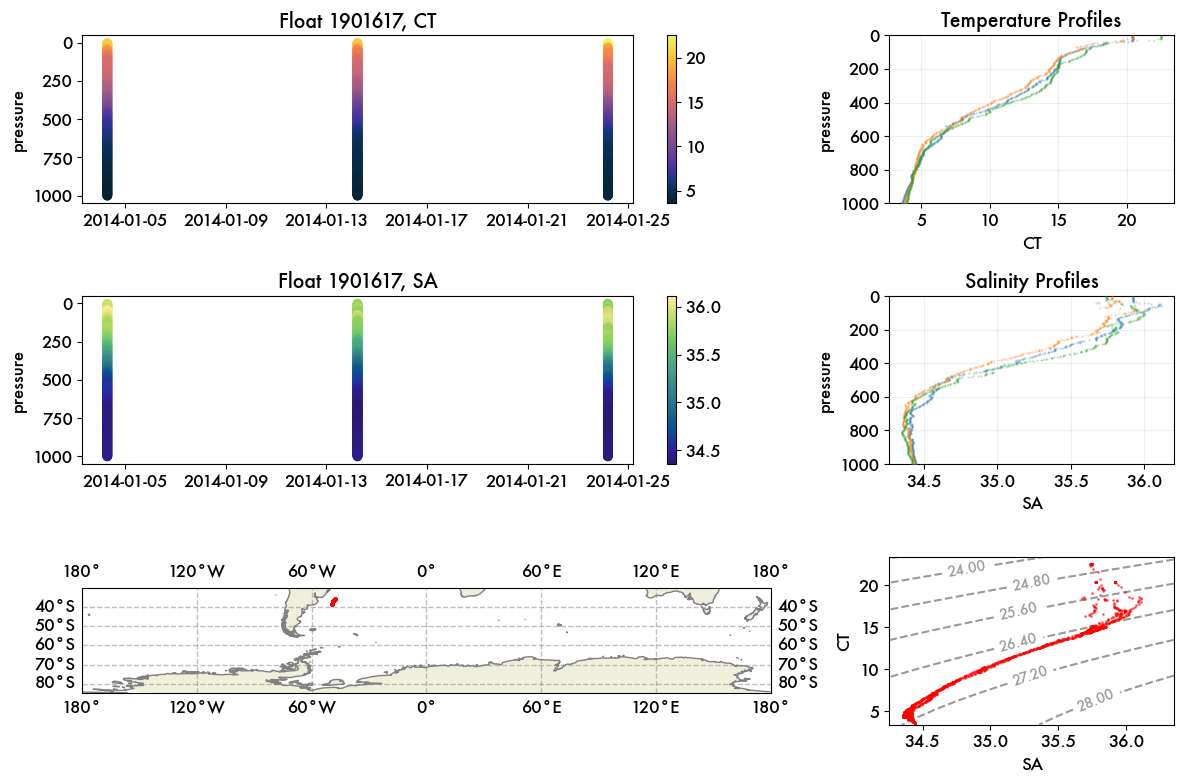

In [539]:
# Plot time series of CT sections for a random float.

reload(crx)
reload(crplot)
reload(mod_argo)
anyfloat, anywmo = crx.get_random_wmo(coreDS)
anyfloat = anyfloat.to_dataframe().reset_index()

fig, axs = mod_argo.plot_TS_diagnostics(anyfloat, figsize=(12,8), dot_small=1, dot_large=4)


# ==== 
# Moving this function to mod_argo 
# fig  = plt.figure(figsize=(12,8), layout='tight')
# # axs = axs.flatten()
# gs = fig.add_gridspec(3,3)
# ax1 = fig.add_subplot(gs[0, 0:2])
# ax2 = fig.add_subplot(gs[1, 0:2])
# ax3 = fig.add_subplot(gs[2, 0:2], projection = ccrs.PlateCarree())

# ax4 = fig.add_subplot(gs[0, 2])
# ax5 = fig.add_subplot(gs[1, 2])
# ax6 = fig.add_subplot(gs[2, 2])

# # ax1 = plt.subplot(311)
# # ax2 = plt.subplot(312)
# # ax3 = plt.subplot(313, projection = ccrs.PlateCarree())

# for ax in [ax1]:
#     sca_CT = ax.scatter(anyfloat.datetime, anyfloat.pressure, c=anyfloat.CT, cmap=cmo.thermal)
#     plt.colorbar(sca_CT)
#     ax.invert_yaxis()
#     ax.set_ylabel('pressure')
#     ax.set_title('Float ' + str(anywmo)[:7] + ', CT')

# for ax in [ax2]:
#     sca_SA = ax.scatter(anyfloat.datetime, anyfloat.pressure, c=anyfloat.SA, cmap=cmo.haline)
#     plt.colorbar(sca_SA)
#     ax.invert_yaxis()
#     ax.set_ylabel('pressure')
#     ax.set_title('Float ' + str(anywmo)[:7] + ', SA')

# for ax in [ax3]:
#     sca_map = ax.scatter(anyfloat.longitude, anyfloat.latitude, c='r', s=14, transform=ccrs.PlateCarree())
#     ax.coastlines(resolution='50m',color='gray')
#     ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
#                  linewidth=1, color='gray', alpha=0.5, linestyle='--')
#     ax.add_feature(cartopy.feature.LAND)

#     ax.set_extent([lon_range[0], lon_range[1], lat_range[0], lat_range[1]], ccrs.PlateCarree())

#     # plt.colorbar(sca_map)

# for ax in [ax4]:
#     mod_argo.plot_profiles_from_WMO(anyfloat, var='CT', ax=ax)
#     ax.set_ylim([1000, 0])
#     ax.set_title('Temperature Profiles')

# for ax in [ax5]:
#     mod_argo.plot_profiles_from_WMO(anyfloat, var='SA', ax=ax)
#     ax.set_ylim([1000, 0])
#     ax.set_title('Salinity Profiles')

# for ax in [ax6]:
#     crplot.setup_TS_contours(anyfloat, ax6, contour_font_size=10)
#     ax.scatter(anyfloat.SA, anyfloat.CT, c='r', s=2, alpha=0.5)


Dates: 		2008-02-25 04:03:00 to 2013-06-01 05:34:00
Latitude:	-48.855 to -34.444
Longitude:	9.045 to 93.926


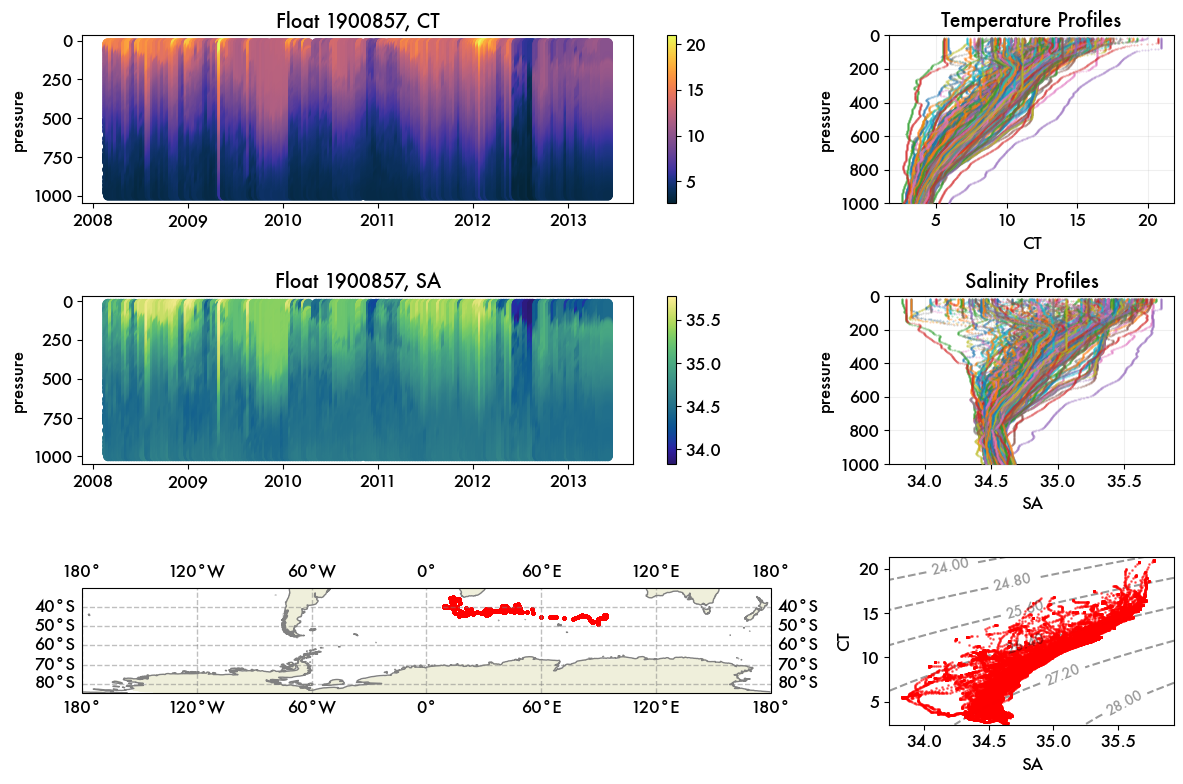

In [540]:
fig, axs = mod_argo.plot_TS_diagnostics(example_df_regular, figsize=(12,8), dot_small=1, dot_large=4)

## T-S diagrams

In [425]:

df = anyfloat
nbins = 50


In [500]:
reload(mod_argo)

wmo_DS, _ = mod_argo.get_wmo_DS(coreDS)
wmo_DS

<xarray.Dataset>
Dimensions:      (profid: 3, pressure: 500)
Coordinates:
  * profid       (profid) object '7900385_id042' '7900385_id043' '7900385_id044'
  * pressure     (pressure) int64 2 4 6 8 10 12 14 ... 990 992 994 996 998 1000
    yearday      (profid, pressure) float64 8.845 8.845 8.845 ... 28.85 28.85
    latitude     (profid, pressure) float64 -67.16 -67.16 ... -67.03 -67.03
    longitude    (profid, pressure) float64 -1.717 -1.717 ... -2.234 -2.234
    wmoid        (profid, pressure) float64 7.9e+06 7.9e+06 ... 7.9e+06 7.9e+06
    datetime     (profid, pressure) datetime64[ns] 2014-01-09T20:16:57 ... 20...
Data variables:
    CT           (profid, pressure) float64 -0.5358 -0.5353 ... 0.409 0.4079
    SA           (profid, pressure) float64 34.13 34.14 34.14 ... 34.86 34.86
    sigma0       (profid, pressure) float64 27.3 27.31 27.31 ... 27.84 27.84
    spice        (profid, pressure) float64 -0.7466 -0.7435 ... -0.1851 -0.1852
    temperature  (profid, pressure) float64 -0.54 -0.5394 ... 0.4556 0.4546
    salinity     (profid, pressure) float64 33.97 33.97 33.98 ... 34.69 34.69
Attributes: (3)

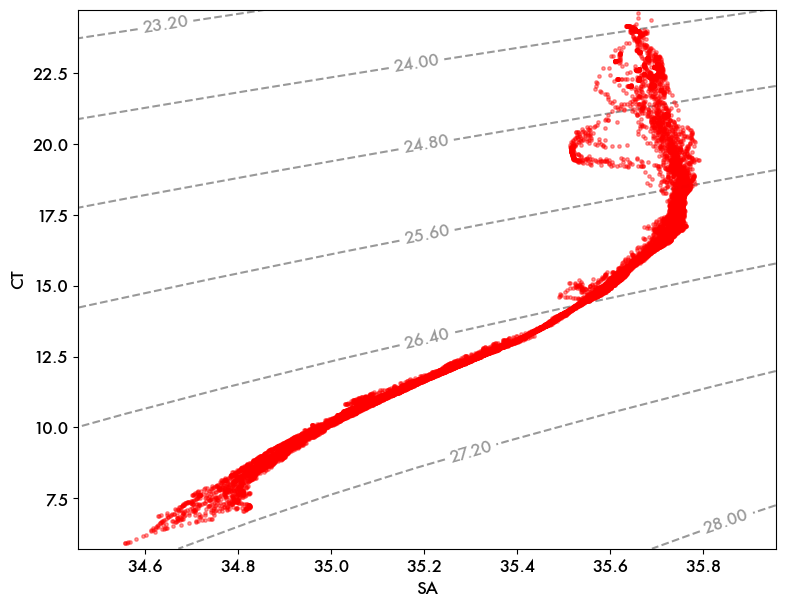

In [484]:
import mod_ocean as myocn 

df = anyfloat
df = mod_argo.get_random_wmo(coreDS)[0]
nbins = 50

# ====== T-S diagram =======
fig = plt.figure(figsize=(9,7))
ax = fig.gca()

crplot.setup_TS_contours(df, ax, contour_font_size=12)

# # For binned
# [bin_temp, bin_sal] = myocn.TSbin(anyfloat, nbins)
# df = myocn.coords_TSbin(df, nbins)
# arr = myocn.array_TSbin(df, nbins, var='CT', stat='count')
# im = plt.pcolormesh(bin_sal, bin_temp, arr, cmap=cmo.matter, zorder=3)
# plt.colorbar(im, ax=ax)

# For normal scatterplot of points
ax.scatter(df.SA, df.CT, c='r', s=6, alpha=0.4, zorder=4)
